In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import statsmodels.api as sm
import seaborn as sb
import pymc as pm
import arviz as az
from sklearn.metrics import roc_curve, auc
from scipy.special import expit  # for logistic function

## Read the Data

In [2]:
data = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_total_weighted_5std_all.csv')
run_data = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_run_weighted_5std_all.csv')
rest_data = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_rest_weighted_5std_all.csv')

## Prepare Data

In [3]:
# rename columns
data.rename(columns={"Event Rate": "Event_Rate"}, inplace=True)
rest_data.rename(columns={"Event Rate": "Event_Rate"}, inplace=True)
run_data.rename(columns={"Event Rate": "Event_Rate"}, inplace=True)

# fit a Bayesian Logistic Regression of the form: Tagged ~ Event_Rate + bias
data_matrix = data[['Event_Rate', 'Population', 'Animal', 'Session', 'Group']]
data_matrix = data_matrix[data_matrix['Session'] == "Baseline"]

# treat the population as a categorical variable where tagged = 1 and non-tagged = 0
data_matrix['Population'] = data_matrix['Population'].astype('category')
data_matrix['Population'] = data_matrix['Population'].cat.codes

# run matrix
run_data_matrix = run_data[['Event_Rate', 'Population', 'Animal', 'Session', 'Group']]
run_data_matrix = run_data_matrix[run_data_matrix['Session'] == "Baseline"].dropna()

# treat the population as a categorical variable where tagged = 1 and non-tagged = 0
run_data_matrix['Population'] = run_data_matrix['Population'].astype('category')
run_data_matrix['Population'] = run_data_matrix['Population'].cat.codes

# rest_matrix
rest_data_matrix = rest_data[['Event_Rate', 'Population', 'Animal', 'Session', 'Group']]
rest_data_matrix = rest_data_matrix[rest_data_matrix['Session'] == "Baseline"].dropna()

# treat the population as a categorical variable where tagged = 1 and non-tagged = 0
rest_data_matrix['Population'] = rest_data_matrix['Population'].astype('category')
rest_data_matrix['Population'] = rest_data_matrix['Population'].cat.codes

combined_data_matrix = run_data_matrix.copy()
combined_data_matrix.rename(columns={"Event_Rate": "Event_Rate_Run"}, inplace=True)

combined_data_matrix['Event_Rate_Rest'] = rest_data_matrix['Event_Rate']

# Set up utility functions and misc. variables

In [ ]:
def logistic(x, slope, bias):
    return 1 / (1 + np.exp(-slope * x - bias))

def plot_data(animal_data, n_bins=10, ax=None, confidence=0.95):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create a copy of the data
    working_data = animal_data.copy()
    
    # bin the data by event rate using qcut instead of cut
    # This ensures approximately equal number of samples in each bin
    working_data['bins'] = pd.qcut(working_data['Event_Rate'], n_bins)
    
    # Rest of the function remains the same
    bin_stats = working_data.groupby('bins').agg({
        'Population': ['mean', 'count']
    })
    
    bin_stats.columns = ['mean', 'count']
    
    z = stats.norm.ppf((1 + confidence) / 2)
    bin_stats['ci_lower'] = bin_stats.apply(lambda x:
        max(0, x['mean'] - z * np.sqrt((x['mean'] * (1 - x['mean'])) / x['count']))
        if x['count'] > 0 and 0 <= x['mean'] <= 1 else np.nan, axis=1)
    
    bin_stats['ci_upper'] = bin_stats.apply(lambda x:
        min(1, x['mean'] + z * np.sqrt((x['mean'] * (1 - x['mean'])) / x['count']))
        if x['count'] > 0 and 0 <= x['mean'] <= 1 else np.nan, axis=1)
    
    valid_bins = working_data.bins.unique()
    midpoints = [bin_val.mid for bin_val in valid_bins if pd.notna(bin_stats.loc[bin_val, 'mean'])]
    
    means = bin_stats['mean'].dropna()
    ci_lower = bin_stats['ci_lower'].dropna()
    ci_upper = bin_stats['ci_upper'].dropna()
    
    ax.vlines(midpoints, ci_lower, ci_upper, color='gray')
    ax.plot(midpoints, means, 'o')
    
    ax.set_xlabel('Event Rate')
    ax.set_ylabel('P(Tagged)')
    ax.set_title('Tagging Probability vs Event Rate')
    
    return ax

def plot_logistic_curves(trace, animal_info, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.linspace(data_matrix['Event_Rate'].min(), data_matrix['Event_Rate'].max(), 100)

    # average over chains then samples
    slopes = trace.posterior.beta_1_individual.mean(axis=0).mean(axis=0).to_numpy()
    biases = trace.posterior.beta_0_individual.mean(axis=0).mean(axis=0).to_numpy()

    for i in range(len(slopes)):
        ax.plot(x, logistic(x, slopes[i], biases[i]), label=animal_info[i])
    
    ax.set_xlabel('Event Rate')
    ax.set_ylabel('P(Tagged)')
    ax.legend()

def get_predicted_probabilities(trace, data_matrix, model_name):
    """
    Calculate predicted probabilities from posterior samples
    """
    # Get the animal indices for prediction
    animal_idx = data_matrix['Animal'].astype('category').cat.codes.values
    
    # Get relevant parameters based on model type
    if model_name == "Combined Model":
        # Get posterior samples - need to handle xarray correctly
        beta_0 = trace.posterior['beta_0_individual'].values
        beta_run = trace.posterior['beta_1_individual_run'].values
        beta_rest = trace.posterior['beta_1_individual_rest'].values
        
        # Reshape to combine chains if necessary
        beta_0 = beta_0.reshape(-1, beta_0.shape[-1])
        beta_run = beta_run.reshape(-1, beta_run.shape[-1])
        beta_rest = beta_rest.reshape(-1, beta_rest.shape[-1])
        
        # Calculate linear predictor for each posterior sample
        n_samples = len(beta_0)
        predictions = np.zeros((n_samples, len(animal_idx)))
        
        for i in range(n_samples):
            mu = (beta_0[i][animal_idx] +
                 beta_run[i][animal_idx] * data_matrix['Event_Rate_Run'].values +
                 beta_rest[i][animal_idx] * data_matrix['Event_Rate_Rest'].values)
            predictions[i] = expit(mu)  # convert logits to probabilities
    
    elif model_name == "Rest Model":
        # Get posterior samples
        beta_0 = trace.posterior['beta_0_individual'].values
        beta_rest = trace.posterior['beta_1_individual'].values
        
        # Reshape to combine chains
        beta_0 = beta_0.reshape(-1, beta_0.shape[-1])
        beta_rest = beta_rest.reshape(-1, beta_rest.shape[-1])
        
        # Calculate linear predictor for each posterior sample
        n_samples = len(beta_0)
        predictions = np.zeros((n_samples, len(animal_idx)))
        for i in range(n_samples):
            mu = (beta_0[i][animal_idx] +
                 beta_rest[i][animal_idx] * data_matrix['Event_Rate_Rest'].values)
            predictions[i] = expit(mu)
    
    elif model_name == "Run Model":
        # Get posterior samples
        beta_0 = trace.posterior['beta_0_individual'].values
        beta_run = trace.posterior['beta_1_individual'].values
        
        # Reshape to combine chains
        beta_0 = beta_0.reshape(-1, beta_0.shape[-1])
        beta_run = beta_run.reshape(-1, beta_run.shape[-1])
        
        # Calculate linear predictor for each posterior sample
        n_samples = len(beta_0)
        predictions = np.zeros((n_samples, len(animal_idx)))
        for i in range(n_samples):
            mu = (beta_0[i][animal_idx] +
                 beta_run[i][animal_idx] * data_matrix['Event_Rate_Run'].values)
            predictions[i] = expit(mu)
            
    return predictions


def plot_roc_with_uncertainty(predictions, y_true, ax=None, color='b', title='ROC Curve with Uncertainty', label_prefix='Mean ROC'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
   
    # Calculate ROC curve for each posterior sample
    n_samples = len(predictions)
    fprs, tprs, aucs = [], [], []
   
    for i in range(n_samples):
        fpr, tpr, _ = roc_curve(y_true, predictions[i])
        fprs.append(fpr)
        tprs.append(tpr)
        aucs.append(auc(fpr, tpr))
   
    # Calculate mean and CI for AUC
    mean_auc = np.mean(aucs)
    ci_lower = np.percentile(aucs, 2.5)
    ci_upper = np.percentile(aucs, 97.5)
   
    # Calculate mean ROC curve and confidence bands
    mean_fpr = np.linspace(0, 1, 100)
    tprs_interp = []
   
    for fpr, tpr in zip(fprs, tprs):
        tprs_interp.append(np.interp(mean_fpr, fpr, tpr))
   
    mean_tpr = np.mean(tprs_interp, axis=0)
    tpr_lower = np.percentile(tprs_interp, 2.5, axis=0)
    tpr_upper = np.percentile(tprs_interp, 97.5, axis=0)
   
    # Plot with custom color
    ax.plot(mean_fpr, mean_tpr, f'{color}-',
            label=f'{label_prefix} (AUC = {mean_auc:.2f} [{ci_lower:.2f}, {ci_upper:.2f}])')
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color=color, alpha=0.2,
                   label=f'95% CI')
    
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
   
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right')
   
    return ax

animals = run_data_matrix['Animal'].unique()
animals_average = data_matrix['Animal'].unique()

### Average Model (use the averaged event rates i.e., event rates for the entire session)

In [18]:
with pm.Model() as average_model:
    # Priors for group-level parameters
    beta_1_group = pm.Normal('beta_1_group', mu=0, sigma=10)
    beta_0_group = pm.Normal('beta_0_group', mu=0, sigma=10)

    # Priors for individual-level parameters
    beta_1_individual = pm.Normal('beta_1_individual', mu=beta_1_group, sigma=1, shape=len(animals_average))
    beta_0_individual = pm.Normal('beta_0_individual', mu=beta_0_group, sigma=1, shape=len(animals_average))

    # Linear predictor
    animal_idx = pm.Data('animal_idx', data_matrix['Animal'].astype('category').cat.codes.values)
    event_rate = pm.Data('event_rate', data_matrix['Event_Rate'].values)

    mu = beta_0_individual[animal_idx] + beta_1_individual[animal_idx] * event_rate

    # Likelihood (Bernoulli)
    y = pm.Bernoulli('y', logit_p=mu, observed=data_matrix['Population'])


### Run Model (consider rates only during running epochs)

In [19]:
with pm.Model() as run_model:
    # set group prior
    beta_1_group = pm.Normal('beta_1_group', mu=0, sigma=10)
    beta_0_group = pm.Normal('beta_0_group', mu=0, sigma=10)

    # set priors for individual-level parameters
    beta_1_individual = pm.Normal('beta_1_individual', mu=beta_1_group, sigma=1, shape=len(animals))
    beta_0_individual = pm.Normal('beta_0_individual', mu=beta_0_group, sigma=1, shape=len(animals))

    # set linear predictor
    # Linear predictor
    animal_idx = pm.Data('animal_idx', run_data_matrix['Animal'].astype('category').cat.codes.values)
    event_rate = pm.Data('event_rate', run_data_matrix['Event_Rate'].values)

    mu = beta_0_individual[animal_idx] + beta_1_individual[animal_idx] * event_rate

    # Likelihood (Bernoulli)
    y = pm.Bernoulli('y', logit_p=mu, observed=run_data_matrix['Population'])


### Rest Model (consider rates only during rest epochs)

In [20]:
with pm.Model() as rest_model:
    # set group prior
    beta_1_group = pm.Normal('beta_1_group', mu=0, sigma=10)
    beta_0_group = pm.Normal('beta_0_group', mu=0, sigma=10)

    # set priors for individual-level parameters
    beta_1_individual = pm.Normal('beta_1_individual', mu=beta_1_group, sigma=1, shape=len(animals))
    beta_0_individual = pm.Normal('beta_0_individual', mu=beta_0_group, sigma=1, shape=len(animals))

    # set linear predictor
    # Linear predictor
    animal_idx = pm.Data('animal_idx', rest_data_matrix['Animal'].astype('category').cat.codes.values)
    event_rate = pm.Data('event_rate', rest_data_matrix['Event_Rate'].values)

    mu = beta_0_individual[animal_idx] + beta_1_individual[animal_idx] * event_rate

    # Likelihood (Bernoulli)
    y = pm.Bernoulli('y', logit_p=mu, observed=rest_data_matrix['Population'])

### Combined Model (consider rates during both running and rest epochs)

In [21]:
# create a new model that considers run and rest event rates
with pm.Model() as combined_model:
    # group prior for run cells
    beta_1_group_run = pm.Normal('beta_1_group_run', mu=0, sigma=10)

    # group prior for rest cells
    beta_1_group_rest = pm.Normal('beta_1_group_rest', mu=0, sigma=10)
    
    # group prior bias
    beta_0_group_bias = pm.Normal('beta_0_group_bias', mu=0, sigma=10)

    # individual priors for run cells
    beta_1_individual_run = pm.Normal('beta_1_individual_run', mu=beta_1_group_run, sigma=1, shape=len(animals))

    # individual priors for rest cells
    beta_1_individual_rest = pm.Normal('beta_1_individual_rest', mu=beta_1_group_rest, sigma=1, shape=len(animals))

    # individual prior for bias
    beta_0_individual = pm.Normal('beta_0_individual', mu=beta_0_group_bias, sigma=1, shape=len(animals))

    animal_idx = pm.Data('animal_idx', combined_data_matrix['Animal'].astype('category').cat.codes.values)
    event_rate_run = pm.Data('event_rate_run', combined_data_matrix['Event_Rate_Run'].values)
    event_rate_rest = pm.Data('event_rate_rest', combined_data_matrix['Event_Rate_Rest'].values)


    # set linear predictor
    mu = beta_0_individual[animal_idx] + beta_1_individual_run[animal_idx] * event_rate_run +  beta_1_individual_rest[animal_idx] * event_rate_rest

    # Likelihood (Bernoulli)
    y = pm.Bernoulli('y', logit_p=mu, observed=combined_data_matrix['Population'])

In [22]:
# Null model with just intercept
with pm.Model() as null_model:
    beta_0_group = pm.Normal('beta_0_group', mu=0, sigma=10)
    beta_0_individual = pm.Normal('beta_0_individual', mu=beta_0_group, sigma=1, shape=len(animals))
    
    animal_idx = pm.Data('animal_idx', rest_data_matrix['Animal'].astype('category').cat.codes.values)
    mu = beta_0_individual[animal_idx]
    
    y = pm.Bernoulli('y', logit_p=mu, observed=rest_data_matrix['Population'])

### Sampling

In [24]:
# sample the models
models = {"Average Model": average_model, 
          "Run Model": run_model, 
          "Rest Model": rest_model, 
          "Combined Model": combined_model,
          "Null Model": null_model}

traces = {}

for model_name, model in models.items():
    with model:
        # sample
        trace = pm.sample(5000, tune=1000, cores=4)
        # calculate loglikelihood for later
        loglikelihood = pm.compute_log_likelihood(trace)
        # save trace
        traces[model_name] = trace
        

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_1_group, beta_0_group, beta_1_individual, beta_0_individual]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 66 seconds.


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_1_group, beta_0_group, beta_1_individual, beta_0_individual]


...

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0_group, beta_0_individual]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 36 seconds.


Output()

In [25]:
import pickle
with open('traces_data.pkl','wb') as tracespkl:
    pickle.dump(traces,tracespkl)

In [26]:
import pickle
with open('traces_data.pkl','rb') as tracespkl:
    data = pickle.load(tracespkl)

In [27]:
traces

{'Average Model': Inference data with groups:
 	> posterior
 	> log_likelihood
 	> sample_stats
 	> observed_data
 	> constant_data,
 'Run Model': Inference data with groups:
 	> posterior
 	> log_likelihood
 	> sample_stats
 	> observed_data
 	> constant_data,
 'Rest Model': Inference data with groups:
 	> posterior
 	> log_likelihood
 	> sample_stats
 	> observed_data
 	> constant_data,
 'Combined Model': Inference data with groups:
 	> posterior
 	> log_likelihood
 	> sample_stats
 	> observed_data
 	> constant_data,
 'Null Model': Inference data with groups:
 	> posterior
 	> log_likelihood
 	> sample_stats
 	> observed_data
 	> constant_data}

### Supp Figure 4B 

In [31]:
animal_mapping={'9972R':'FC1','992N':'FC2','989N':'FC3',
           '149L':'FC4','146R':'FC5','160R':'FC6','492N':'FC7','493R':'FC8',
           '589L':'HC1','992L':'HC2','994R':'HC3',
           '034R':'HC4','217N':'HC5','218L':'HC6','217R':'HC7','1912L':'HC8'}

DF = pd.DataFrame()
# Step 3: Create a DataFrame to visualize results
for model,trace in zip(['rest','run'],[data['Rest Model'],data['Run Model']]):
    mean_beta1s = trace.posterior['beta_1_individual'].mean(axis=(0, 1))  # Shape will be (len(animals),)
    df = pd.DataFrame({'Animal': [animal_mapping[i] for i in animals],'beta': mean_beta1s,'Model':[model]*len(animals)})
    DF = pd.concat([DF,df],ignore_index=True)

In [32]:
DF_c = pd.DataFrame()
for r,beta in zip(['rest','run'],['beta_1_individual_rest','beta_1_individual_run']):
    mean_betas1 = data['Combined Model'].posterior[beta].mean(axis=(0,1))
    df = pd.DataFrame({'Animal': [animal_mapping[i] for i in animals],'beta': mean_betas1.values,'coeff':[r]*len(animals)})
    DF_c = pd.concat([DF_c,df],ignore_index=True)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_56563/4173789431.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels([r'$\beta_{1 rest}$',r'$\beta_{1 run}$'])
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_56563/4173789431.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels([r'$\beta_{1 rest}$',r'$\beta_{1 run}$'])


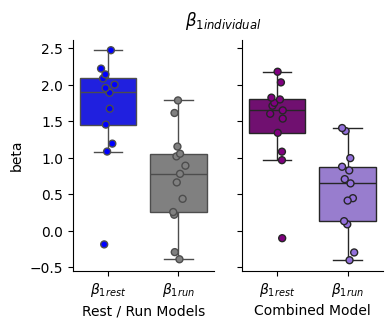

In [34]:
fig,ax = plt.subplots(ncols=2,nrows=1,sharey=True,figsize=(4,3))
colors = ['blue','gray','purple','mediumpurple']
sb.boxplot(data=DF,x='Model',y='beta',ax=ax[0],hue='Model',showfliers=False,palette=colors[0:2])
sb.stripplot(data=DF,x='Model',y='beta',ax=ax[0],hue='Model',palette=colors[0:2],linewidth=1)
ax[0].set_xlabel('Rest / Run Models')
ax[0].set_xticklabels([r'$\beta_{1 rest}$',r'$\beta_{1 run}$'])
sb.boxplot(data=DF_c,x='coeff',y='beta',ax=ax[1],hue='coeff',showfliers=False,palette=colors[2:])
sb.stripplot(data=DF_c,x='coeff',y='beta',ax=ax[1],hue='coeff',palette=colors[2:],linewidth=1)
ax[1].set_xlabel('Combined Model')
ax[1].set_xticklabels([r'$\beta_{1 rest}$',r'$\beta_{1 run}$'])
plt.suptitle(r'$\beta_{1 individual}$')

sb.despine()
plt.savefig('beta1_boxplots_indiv.svg',transparent=True)

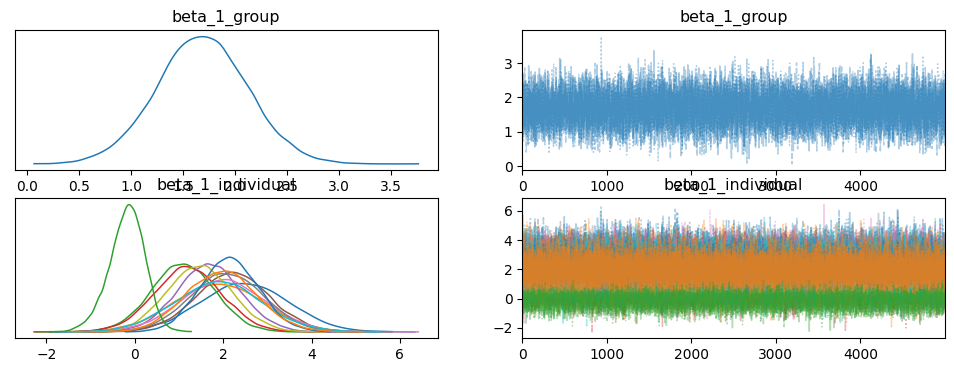

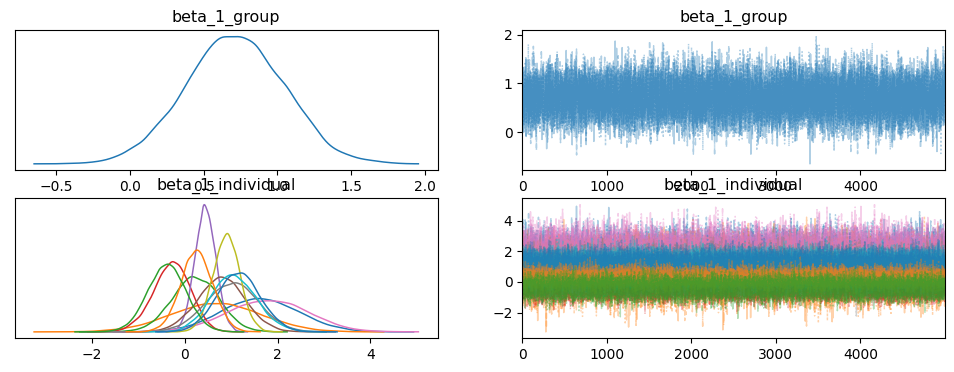

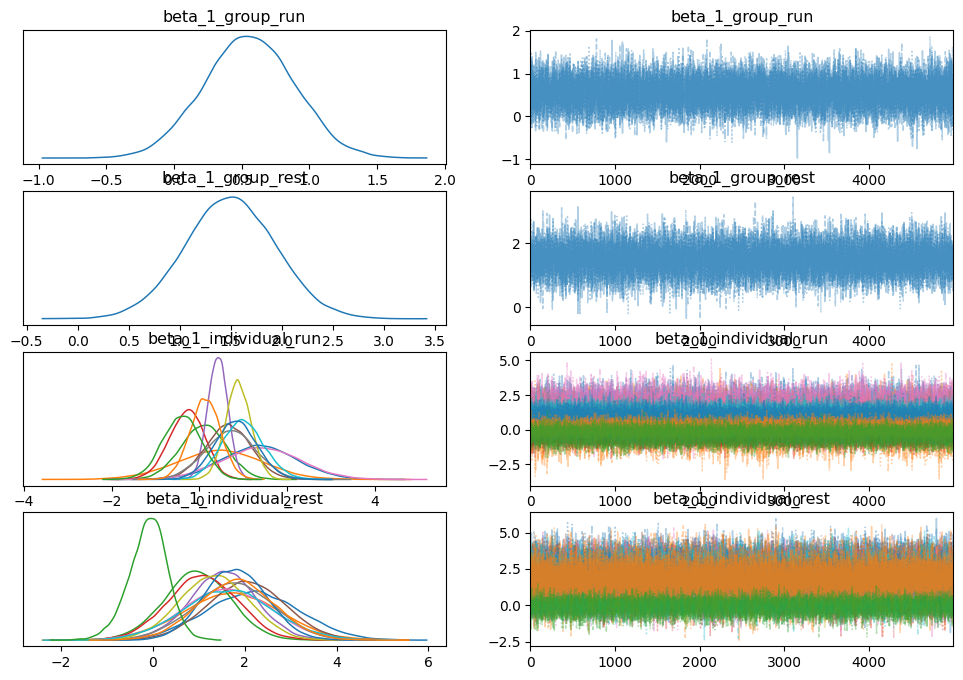

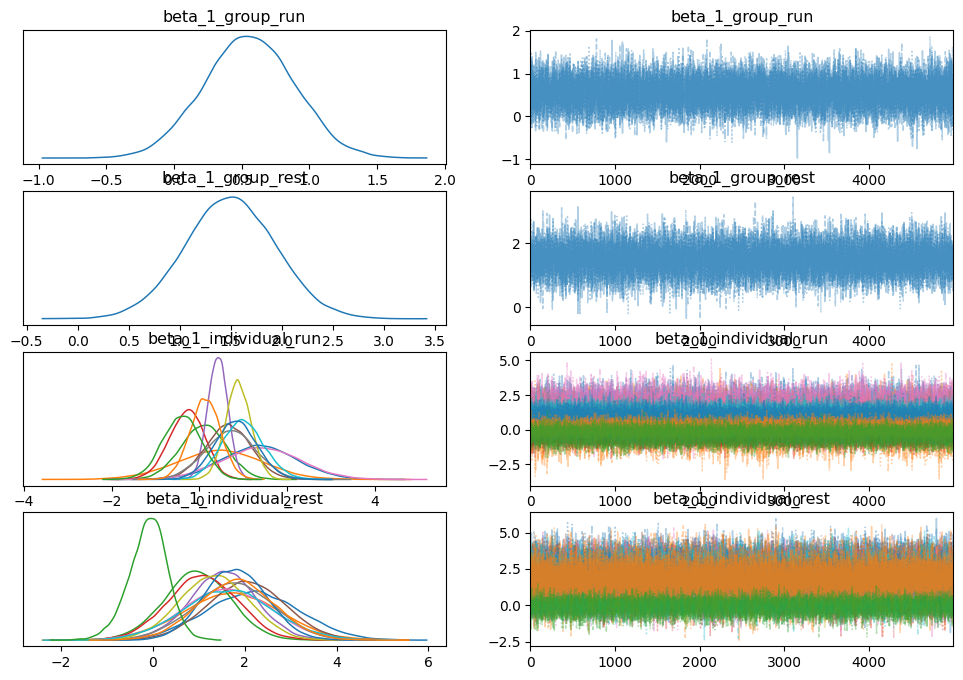

In [35]:
ax0=az.plot_trace(data['Rest Model'],var_names=('^beta_1'), filter_vars="regex",combined=True)[0][0] #group level rest beta0
ax1=az.plot_trace(data['Run Model'],var_names=('^beta_1'), filter_vars="regex",combined=True)[0][0] #group level rest beta0
ax2=az.plot_trace(data['Combined Model'],var_names=('^beta_1'), filter_vars="regex",combined=True)[1][0] #group level rest beta1
ax3=az.plot_trace(data['Combined Model'],var_names=('^beta_1'), filter_vars="regex",combined=True)[0][0] #group level run beta1

# Supp Fig 4C - Plot posterior



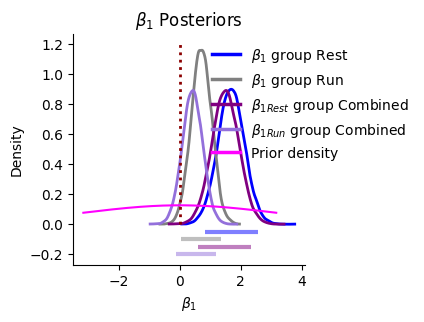

In [37]:
traces = [data['Rest Model'],data['Run Model']]
colors = ['blue','gray','purple','mediumpurple']
fig, ax = plt.subplots(figsize=(3,3))
j=0
k=0
# Copy the density curve from the original axes to the new plot
for trace,a in zip(traces,[ax0,ax1]):
#group level posterior
    for i,line in enumerate(a.get_lines()):
        ax.plot(line.get_xdata(), line.get_ydata(), color=colors[k], linewidth=2)

#group level 95% hdi
    hdi_values0 = az.hdi(trace.posterior['beta_1_group'], hdi_prob=0.95).to_array().values  # e.g., 95% HDI
    ax.hlines(xmin=hdi_values0[0][0],xmax=hdi_values0[0][1],y=-0.05-j,linewidth=3,alpha=0.5,colors=colors[k])
    j=j+.05
    k=k+1

ax.plot(ax2.get_lines()[0].get_xdata(),ax2.get_lines()[0].get_ydata(), color=colors[2], linewidth=2)
hdi_values1 = az.hdi(data['Combined Model'].posterior['beta_1_group_rest'], hdi_prob=0.95).to_array().values  # e.g., 95% HDI
ax.hlines(xmin=hdi_values1[0][0],xmax=hdi_values1[0][1],y=-0.15,linewidth=3,alpha=0.5,colors=colors[2])
hdi_values2 = az.hdi(data['Combined Model'].posterior['beta_1_group_run'], hdi_prob=0.95).to_array().values  # e.g., 95% HDI
ax.hlines(xmin=hdi_values2[0][0],xmax=hdi_values2[0][1],y=-0.2,linewidth=3,alpha=0.5,colors=colors[3])

ax.plot(ax3.get_lines()[0].get_xdata(),ax2.get_lines()[0].get_ydata(), color=colors[3], linewidth=2)
#create line objects for control over colors and labels
custom_lines = [plt.Line2D([0], [0], color=colors[0], lw=2.5),  #red line
                plt.Line2D([0], [0], color=colors[1], lw=2.5),
                plt.Line2D([0], [0], color=colors[2], lw=2.5),
                plt.Line2D([0], [0], color=colors[3], lw=2.5),
                plt.Line2D([0], [0], color='magenta', lw=2.5)]  #blue line

# Create the legend with custom labels
ax.legend(custom_lines, [r"$\beta_{1}$"+ " group Rest", r"$\beta_{1}$"+ " group Run",r"$\beta_{1 Rest}$"+ " group Combined",r"$\beta_{1 Run}$"+ " group Combined",'Prior density'], 
          loc="upper right",bbox_to_anchor=(1.5,1),frameon=False)

ax.set_title(r"$\beta_{1}$"+' Posteriors')
ax.set_ylabel("Density")
ax.set_xlabel(r"$\beta_{1}$")

from scipy.stats import norm

# Define parameters
mu = 0            # Mean
variance = 10     # Variance
sigma = np.sqrt(variance)  # Standard deviation
# Generate x values for the plot
x = np.linspace(mu - 1*sigma, mu + 1*sigma, 1000)
# Get the PDF values
pdf = norm.pdf(x, loc=mu, scale=sigma)
# Plot the PDF
plt.plot(x, pdf, label=f'Normal PDF (μ={mu}, σ²={variance})',color='magenta')


#plt.yscale('log')
sb.despine()
plt.vlines(0,0,1.2,color='darkred',linestyle='dotted',linewidth=2)
plt.savefig('beta1_group_posteriors.svg',transparent=True)

### Supp Figure 4D - model comparison

In [47]:
traces_without_averaged = {k: v for k, v in traces.items() if k != "Average Model"}
loos = az.compare(traces_without_averaged)
loos

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Combined Model,0,-2438.357684,27.928763,0.000000,5.436091e-01,26.565294,0.000000,True,log
Rest Model,1,-2443.473794,18.780425,5.116110,2.959517e-01,26.187104,4.851331,False,log
Run Model,2,-2445.486170,22.223373,7.128486,1.604392e-01,26.291468,4.433525,False,log
Null Model,3,-2456.176457,12.825294,17.818773,3.996803e-15,25.853338,7.207037,False,log


In [48]:
loos.to_csv('model_lood.csv')

In [49]:
loos = pd.read_csv('model_lood.csv')

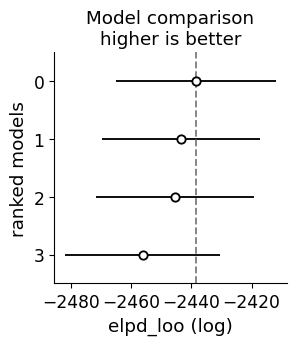

In [51]:
fig,ax=plt.subplots(figsize=(3,3))
az.plot_compare(loos,ax=ax)
sb.despine()
plt.savefig('elpd_loo_compare.svg',transparent = True)